### 자전거 수요 예측
* 자전거 수요를 파악하여 효율적으로 자전거 대여수를 예측하고자 한다
* 월, 일, 시 별로 언제 자전거를 많이 대여하는지를 파악한다
>
* 컬럼
    - datetime : 대여 날짜
    - season : 1(봄), 2(여름), 3(가을), 4(겨울)
    - holiday : 1(토,일 주말을 제외한 국경일 등의 휴일), 0(휴일이 아닌 날)
    - workingday : 1(토, 일 주말 및 휴일이 아닌 주중), 0(주말 및 휴일)
    - weather : 1(맑음), 2(흐림), 3(가벼운 눈, 비), 4(심한 눈, 비)
    - temp : 온도(섭씨)
    - atemp : 체감온도(섭씨)
    - humidity : 습도
    - windspeed : 풍속
    - casual : 비등록 대여 횟수
    - registered : 등록 대여 횟수
    - count : 총 대여 횟수

In [1]:
import pandas as pd

In [3]:
df = pd.read_csv('../data_set/6.회귀/data.csv')
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


In [5]:
df['datetime'] = df['datetime'].apply(pd.to_datetime)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[us]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(8)
memory usage: 1020.7 KB


In [8]:
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].apply(lambda x : x.day)
df['hour'] = df['datetime'].apply(lambda x : x.hour)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[us]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int64         
 15  hour        10886 non-null  int64         
dtypes: datetime64[us](1), float64(3),

In [10]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4


### 데이터 탐색

In [11]:
d = df.groupby('hour').agg({'count' : 'sum'}).reset_index()

In [12]:
d

,hour,count
0,0,25088
1,1,15372
2,2,10259
3,3,5091
4,4,2832
5,5,8935
6,6,34698
7,7,96968
8,8,165060
9,9,100910


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

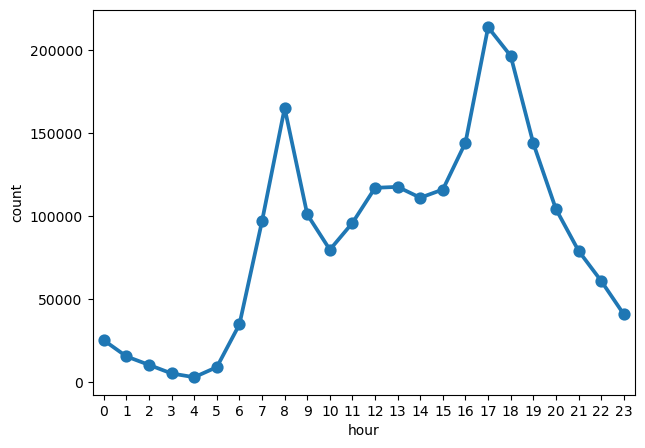

In [14]:
plt.figure(figsize=(7, 5))
sns_result = sns.pointplot(data=d, x='hour', y='count')

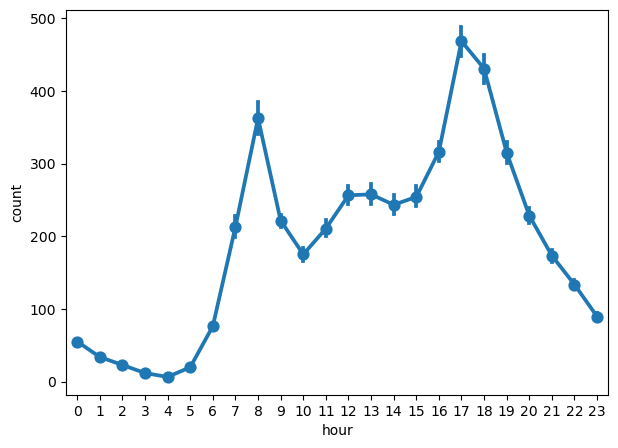

In [17]:
plt.figure(figsize=(7, 5))
sns_result = sns.pointplot(data=df, x='hour', y='count') # 평균값 표현

In [15]:
d = df.groupby( ['hour', 'workingday']).agg({'count':'sum'}).reset_index()
d

,hour,workingday,count
0,0,0,13701
1,0,1,11387
2,1,0,10427
3,1,1,4945
4,2,0,7686
5,2,1,2573
6,3,0,3677
7,3,1,1414
8,4,0,1239
9,4,1,1593


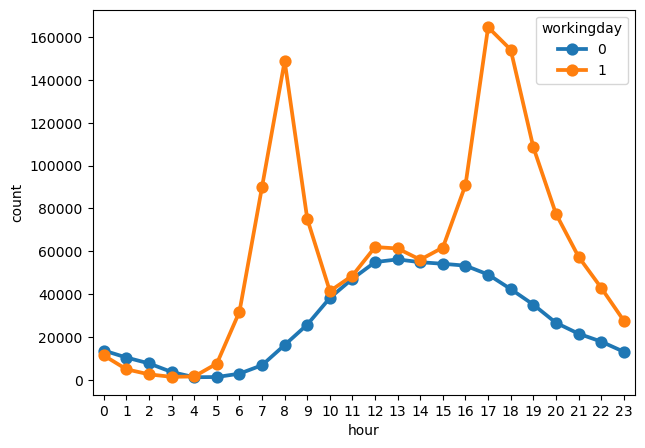

In [18]:
plt.figure(figsize=(7, 5))
sns_result = sns.pointplot(data=d, x='hour', y='count', hue='workingday')

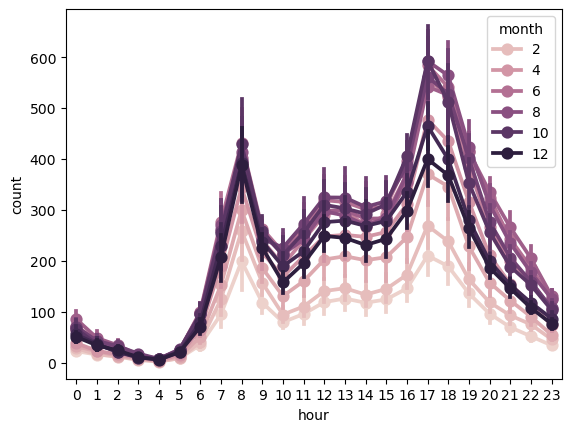

In [19]:
sns_result = sns.pointplot(data=df, x='hour', y='count', hue='month')

In [20]:
d = df.groupby( ['hour', 'month']).agg({'count':'sum'}).reset_index()
d

,hour,month,count
0,0,1,852
1,0,2,1096
2,0,3,1249
3,0,4,1480
4,0,5,2441
...,...,...,...
283,23,8,4791
284,23,9,4092
285,23,10,3949
286,23,11,3310


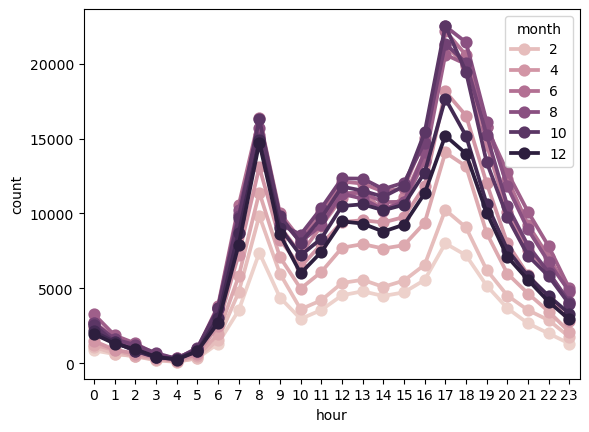

In [21]:
sns_result = sns.pointplot(data=d, x='hour', y='count', hue='month')

In [22]:
d = df.groupby( ['hour', 'weather']).agg({'count':'sum'}).reset_index()
d

,hour,weather,count
0,0,1,18214
1,0,2,6106
2,0,3,768
3,1,1,10397
4,1,2,4246
...,...,...,...
68,22,2,12206
69,22,3,2567
70,23,1,29551
71,23,2,8745


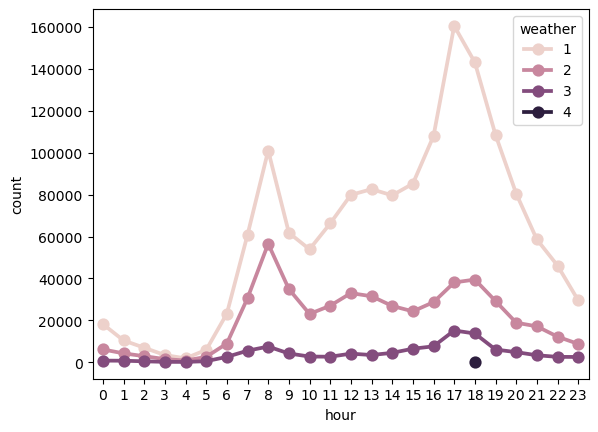

In [23]:
sns_result = sns.pointplot(data=d, x='hour', y='count', hue='weather')

In [24]:
d = df.groupby( ['month']).agg({'registered':'sum', 'casual':'sum'}).reset_index()
d

,month,registered,casual
0,1,72632,7252
1,2,89816,9297
2,3,108445,25056
3,4,127589,39813
4,5,158862,41285
5,6,172159,48574
6,7,163670,50947
7,8,167646,45870
8,9,166628,45901
9,10,169347,38087


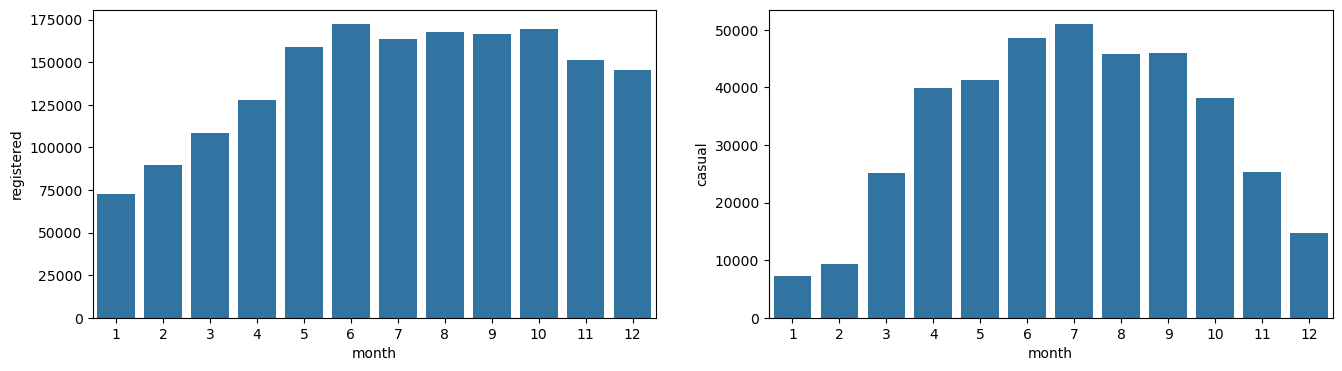

In [26]:
figure, (ax1, ax2) = plt.subplots(ncols=2)
figure.set_size_inches(16,4)

sns.barplot(data=d, x='month', y='registered', ax=ax1)
sns.barplot(data=d, x='month', y='casual', ax=ax2)

plt.show()

In [27]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4


In [28]:
df['temp_int'] = df['temp'].apply(int)

In [29]:
df['temp_int']

0         9
1         9
2         9
3         9
4         9
         ..
10881    15
10882    14
10883    13
10884    13
10885    13
Name: temp_int, Length: 10886, dtype: int64

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[us]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int64         
 15  hour        10886 non-null  int64         
 16  temp_int    10886 non-null  int64

In [31]:
d = df.groupby( ['temp_int', 'workingday']).agg({'registered':'sum', 'casual':'sum', 'count':'sum'}).reset_index()
d

,temp_int,workingday,registered,casual,count
0,0,1,538,6,544
1,1,1,176,7,183
2,2,1,204,11,215
3,3,0,75,1,76
4,3,1,128,8,136
...,...,...,...,...,...
72,37,1,5359,1413,6772
73,38,0,658,323,981
74,38,1,516,175,691
75,39,0,1269,638,1907


C:\Users\user\AppData\Local\Temp\ipykernel_17404\2927753599.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1_sns.set_xticklabels(ax1_sns.get_xticklabels(), rotation=50)
C:\Users\user\AppData\Local\Temp\ipykernel_17404\2927753599.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2_sns.set_xticklabels(ax2_sns.get_xticklabels(), rotation=50)
C:\Users\user\AppData\Local\Temp\ipykernel_17404\2927753599.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3_sns.set_xticklabels(ax3_sns.get_xticklabels(), rotation=50)
C:\Users\user\AppData\Local\Temp\ipykernel_17404\2927753599.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4_sns.set_xticklabel

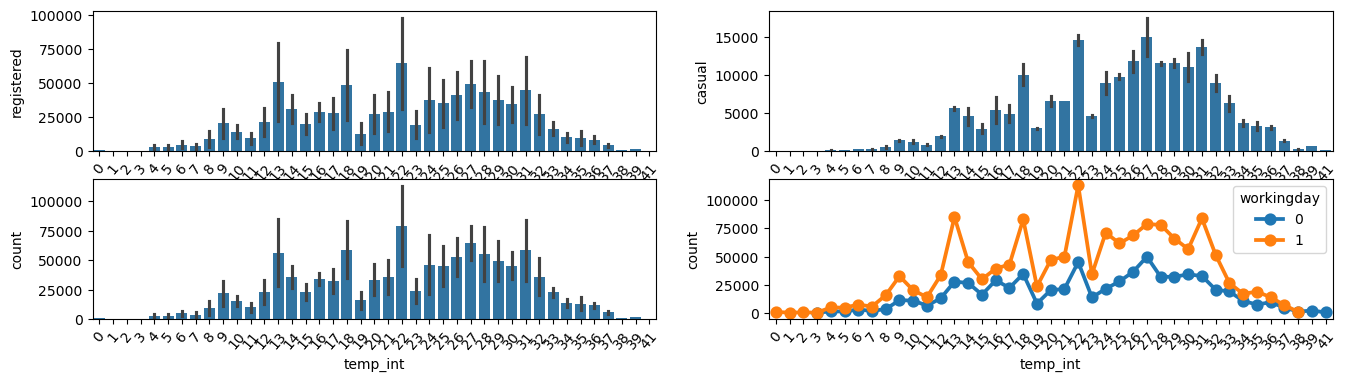

In [40]:
figure, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2)
figure.set_size_inches(16,4)

ax1_sns = sns.barplot(data=d, x='temp_int', y='registered', ax=ax1) # ci=False(평균, 편차 나타내는 검은 것 없앰
ax1_sns.set_xticklabels(ax1_sns.get_xticklabels(), rotation=50)

ax2_sns = sns.barplot(data=d, x='temp_int', y='casual', ax=ax2)
ax2_sns.set_xticklabels(ax2_sns.get_xticklabels(), rotation=50)

ax3_sns = sns.barplot(data=d, x='temp_int', y='count', ax=ax3)
ax3_sns.set_xticklabels(ax3_sns.get_xticklabels(), rotation=50)

ax4_sns = sns.pointplot(data=d, x='temp_int', y='count', hue='workingday', ax=ax4)
ax4_sns.set_xticklabels(ax4_sns.get_xticklabels(), rotation=50)

plt.show()

#### 모델링

In [41]:
df.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count',
       'year', 'month', 'day', 'hour', 'temp_int'],
      dtype='str')

In [42]:
f = ['season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'year', 'month', 'day', 'hour']
label = 'count'

X, y = df[f], df[label]

In [43]:
from sklearn.model_selection import train_test_split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [45]:
from sklearn.ensemble import RandomForestRegressor

In [46]:
rfr = RandomForestRegressor()
rfr.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [47]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

In [48]:
pred = rfr.predict(X_test)

mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, pred)

In [53]:
print('mse :', mse)
print('rmse :', rmse)
print('mae :', mae)

print("정상 범주에 있다" , rmse < (mae * 1.5))
print("약간 오차가 있다" , rmse >= (mae * 1.5))
print("오차가 큰 게 있다" , rmse > (mae * 2))

print('train :', rfr.score(X_train, y_train))
print('test :', rfr.score(X_test, y_test))


mse : 2013.5355345070423
rmse : 44.8724362443922
mae : 27.65691671769749
정상 범주에 있다 False
약간 오차가 있다 True
오차가 큰 게 있다 False
train : 0.9919845241665177
test : 0.9353046329822922


In [54]:
params = {
    'n_estimators' : range(5, 100, 10), # 트리 계수
    'max_depth' : range(4, 11, 2), # 최대 깊이
    'min_samples_split' : range(4, 21, 4) # 노드 분할 최소한의 샘플 수
}

In [55]:
from sklearn.model_selection import GridSearchCV

In [56]:
rfr = RandomForestRegressor()
grid_cv = GridSearchCV(rfr, param_grid=params, cv=3, n_jobs=-1)
grid_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': range(4, 11, 2), 'min_samples_split': range(4, 21, 4), 'n_estimators': range(5, 100, 10)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >

In [57]:
pred = grid_cv.predict(X_test)

mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, pred)

In [60]:
print('mse :', mse)
print('rmse :', rmse)
print('mae :', mae)

print("정상 범주에 있다" , rmse < (mae * 1.5))
print("약간 오차가 있다" , rmse >= (mae * 1.5))
print("오차가 큰 게 있다" , rmse > (mae * 2))

print('train :', grid_cv.score(X_train, y_train))
print('test :', grid_cv.score(X_test, y_test))


print('최적의 파라미터 : ', grid_cv.best_params_)

mse : 2501.7218999848715
rmse : 50.017216035929785
mae : 31.97073073581232
정상 범주에 있다 False
약간 오차가 있다 True
오차가 큰 게 있다 False
train : 0.9506463835191211
test : 0.919619091035618
최적의 파라미터 :  {'max_depth': 10, 'min_samples_split': 8, 'n_estimators': 95}


In [61]:
df_result = pd.DataFrame({
    'y_test' : [11, 12, 13, 14, 15, 16, 17, 18, 19], # 11~19
    'y_pred' : [10, 11, 12, 13, 14, 15, 16, 17, 18]
})

<Axes: >

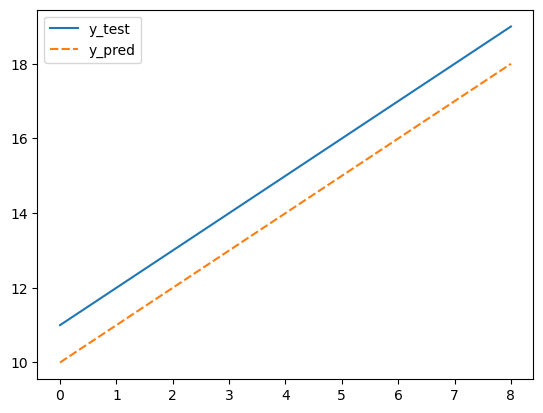

In [62]:
sns.lineplot(data=df_result)

In [65]:
range_start = 0
range_end = 30

y_pred = grid_cv.predict(X_test)

y_test_reset = y_test[range_start:range_end].reset_index()
y_test_reset['y_pred'] = y_pred[range_start : range_end]

y_test_reset['y_pred'] = y_test_reset['y_pred'].apply(int)
y_test_reset

,index,count,y_pred
0,9059,274,300
1,1854,3,4
2,86,182,159
3,10692,106,140
4,4178,5,5
5,6111,122,143
6,2287,28,25
7,7020,282,277
8,10865,5,6
9,6229,311,318


<Axes: >

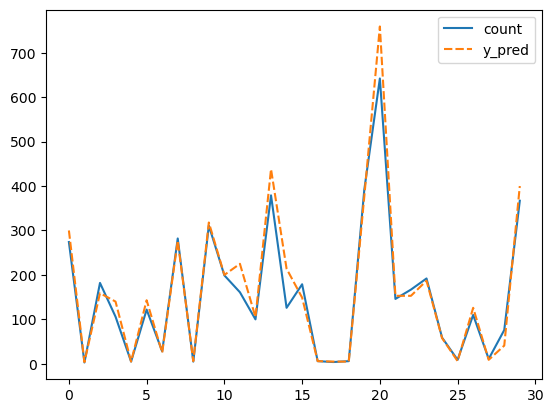

In [66]:
sns.lineplot(data=y_test_reset[['count','y_pred']])